# Proposal

1. Introduction

Introduction

The rapid growth of digital information has resulted in a significant increase in the availability of textual data across multiple domains, including health and mental health research. Articles, reports, and online publications discussing mental health contain valuable insights regarding psychological conditions, treatments, public awareness, and emotional well-being. However, the large volume of unstructured text makes manual analysis inefficient and impractical. Consequently, Natural Language Processing (NLP) and machine learning techniques provide effective tools for extracting meaningful patterns, relationships, and insights from such textual data.

This study applies machine learning–based text analysis methods to explore and model a collection of mental health–related articles. The goal is to transform raw textual information into structured representations that allow computational analysis, discovery of underlying patterns, and predictive modelling. The workflow follows a structured analytical pipeline beginning with data exploration, followed by text preprocessing and feature engineering, and subsequently applying machine learning techniques for similarity analysis, clustering, and classification.

The first stage of the analysis involves Exploratory Data Analysis (EDA) of the textual dataset. This step examines the structure and characteristics of the data, including document lengths, vocabulary distribution, and frequently occurring words or phrases. EDA provides an initial understanding of the dataset and helps identify patterns that may influence the modelling process.

Following exploration, the text data is prepared through preprocessing techniques such as tokenization, normalization, stop-word removal, and other cleaning procedures. These steps reduce noise in the dataset and ensure that only meaningful textual information is retained for further analysis. The cleaned text is then converted into numerical representations using feature engineering methods such as Bag-of-Words and Term Frequency–Inverse Document Frequency (TF-IDF). These representations enable machine learning algorithms to interpret textual information quantitatively.

Once the textual data is represented numerically, text similarity analysis is performed to measure how closely related different documents are based on their content. Similarity measures such as cosine similarity allow the identification of articles discussing comparable mental health themes or topics. This step provides insight into relationships within the dataset and supports the identification of related information sources.

The study also applies unsupervised machine learning techniques, particularly clustering algorithms, to discover hidden structures in the dataset. Clustering groups articles with similar linguistic patterns or thematic content without relying on predefined labels. This allows the identification of natural topic groupings within the mental health literature, such as discussions about anxiety, depression, therapy approaches, or mental health awareness.

In addition to unsupervised analysis, supervised machine learning models are used for text classification, where algorithms are trained to categorize documents based on their textual features. Classification models learn patterns from labelled data and attempt to predict the category or topic of unseen documents. By comparing multiple machine learning models, the study evaluates how effectively different algorithms can classify mental health articles based on their linguistic characteristics.

Overall, this machine learning framework demonstrates how NLP techniques can transform unstructured mental health text into actionable insights. Through the integration of exploratory analysis, similarity measurement, clustering, and predictive classification, the study highlights the potential of machine learning methods for understanding patterns in mental health–related textual data and supporting data-driven research in the field.

# 2. Data Collection


In [3]:
# ==========================================
# PHASE 0: SETUP, LIBRARIES & ENVIRONMENT CONFIGURATION
# ==========================================

import sys
import subprocess
import pkg_resources
import os
import re
import warnings

# --- 1. AUTO-INSTALL MISSING DEPENDENCIES ---
# This must run BEFORE importing third-party libraries to prevent crashes
required_packages = {
    'pypdf', 'pymupdf', 'spacy', 'wordcloud', 'plotly',
    'scipy', 'networkx', 'scikit-learn', 'nltk', 'pandas'
}
installed_packages = {pkg.key for pkg in pkg_resources.working_set}
missing_packages = required_packages - installed_packages

if missing_packages:
    print(f"Installing missing packages: {', '.join(missing_packages)}...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages, "-q"])

# --- 2. DATA SCIENCE & MATH ---
import pandas as pd
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.cluster.hierarchy import dendrogram, linkage
import heapq
from itertools import combinations

# --- 3. NLP & TEXT PROCESSING ---
import spacy
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.text import Text
from nltk.sentiment import SentimentIntensityAnalyzer

# --- 4. VISUALIZATION ---
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud

# --- 5. NETWORK ANALYSIS ---
import networkx as nx
from networkx.algorithms import community

# --- 6. MACHINE LEARNING ---
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, PCA
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score, davies_bouldin_score, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, LeaveOneOut, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# --- 7. PDF PROCESSING & UTILS ---
import fitz  # PyMuPDF
from pypdf import PdfReader
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# --- 8. CONFIGURATION & DOWNLOADS ---
# Suppress annoying warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

print("Downloading NLTK resources...")
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('vader_lexicon', quiet=True)

print("Loading SpaCy NLP model...")
try:
    nlp = spacy.load("en_core_web_sm")
except (ImportError, OSError):
    print("SpaCy model not found. Downloading...")
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm", "-q"])
    nlp = spacy.load("en_core_web_sm")

print("\n \ PHASE 0 COMPLETE: Environment is fully configured and ready.")

<>:94: SyntaxWarning: invalid escape sequence '\ '
<>:94: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_350/923602912.py:94: SyntaxWarning: invalid escape sequence '\ '
  print("\n \ PHASE 0 COMPLETE: Environment is fully configured and ready.")


Installing missing packages: pymupdf, pypdf...
Loading SpaCy NLP model...

 \ PHASE 0 COMPLETE: Environment is fully configured and ready.


Import Library

In [4]:


# ==========================================
# 2. CONFIGURATION AND UTILITY FUNCTIONS
# ==========================================

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
DIRECTORY_PATH = "/content/drive/MyDrive/HEel SPur Study"



Mounted at /content/drive


Load Library

In [5]:
# ==========================================
# UNIVERSAL NLP PREPROCESSING MODULE (BULLETPROOF)
# ==========================================
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# 1. Safely download ONLY the required processing tools (no stopword corpus needed)
for package in ['tokenizers/punkt', 'corpora/wordnet', 'tokenizers/punkt_tab']:
    try:
        nltk.data.find(package)
    except LookupError:
        package_name = package.split('/')[-1]
        nltk.download(package_name, quiet=True)

# 2. Initialize Lemmatizer
_lemmatizer = WordNetLemmatizer()

# 3. Hardcode standard English stopwords to guarantee removal
_base_stopwords = {
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd",
    'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers',
    'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which',
    'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been',
    'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if',
    'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between',
    'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out',
    'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why',
    'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not',
    'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', "don't",
    'should', "should've", 'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', "aren't", 'couldn',
    "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't",
    'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't",
    'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"
}

# 4. Define custom/domain-specific stopwords here
_custom_stopwords = {
    'study', 'method', 'result', 'conclusion', 'patient', 'group',
    'et', 'al', 'background', 'doi', 'journal', 'significant', 'analysis',
    'objective', 'purpose', 'aim', 'introduction', 'materials', 'methods',
    'article', 'review', 'author', 'published', 'clinical'
}

# 5. Combine into final stopword set
FINAL_STOPWORDS = _base_stopwords.union(_custom_stopwords)

def clean_and_tokenize(text, remove_numbers=True, min_word_length=2):
    """
    A universal text cleaning function.
    Takes a raw string and returns a cleaned, lemmatized string without stopwords.
    """
    if not isinstance(text, str):
        return ""

    text = text.lower()

    # Noise removal
    text = re.sub(r'http\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'\S+@\S+', '', text)         # Remove emails

    if remove_numbers:
        text = re.sub(r'\d+', '', text)         # Remove numbers

    # Keep only alphabetic characters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Filter stopwords, enforce minimum length, and lemmatize
    clean_tokens = [
        _lemmatizer.lemmatize(token)
        for token in tokens
        if token not in FINAL_STOPWORDS and len(token) > min_word_length
    ]

    return " ".join(clean_tokens)

In [6]:
# ==========================================
# PHASE 1: DATA INGESTION & STRUCTURING
# ==========================================


# Install PyPDF2 if it's not already installed
try:
    from PyPDF2 import PdfReader
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "PyPDF2"])
    from PyPDF2 import PdfReader


def build_text_corpus(directory_path):
    """
    Machine Learning Data Ingestion Pipeline
    1. Detects PDF documents
    2. Extracts raw text
    3. Cleans empty documents
    4. Returns structured corpus as a DataFrame (df)
    """

    if not os.path.exists(directory_path):
        raise FileNotFoundError(f"Directory not found: {directory_path}")

    documents = []

    print(f"Scanning directory: {directory_path}...")
    for filename in os.listdir(directory_path):
        if filename.lower().endswith(".pdf"):
            file_path = os.path.join(directory_path, filename)

            try:
                reader = PdfReader(file_path)
                text = ""

                for page in reader.pages:
                    extracted = page.extract_text()
                    if extracted:
                        text += extracted + " "

                # Remove extremely short or empty documents
                if len(text.strip()) > 100:
                    documents.append({
                        "filename": filename,
                        "raw_text": text.strip()
                    })

            except Exception as e:
                print(f"Error processing {filename}: {e}")

    if len(documents) == 0:
        raise ValueError("No valid text documents extracted. Check your folder path.")

    df = pd.DataFrame(documents)

    print(f"Successfully built corpus with {len(df)} documents.")
    return df


# ---------------------------------------------------------
# EXECUTE THE PIPELINE
# ---------------------------------------------------------



df = build_text_corpus(DIRECTORY_PATH)

Scanning directory: /content/drive/MyDrive/HEel SPur Study...
Successfully built corpus with 196 documents.


In [7]:
# ==========================================
# PHASE 2: METADATA EXTRACTION FROM PDF TEXT
# ==========================================

import re

def extract_year(text):
    years = re.findall(r"(19\d{2}|20\d{2})", text)
    return years[0] if years else None


def extract_title(text):
    lines = text.split("\n")
    for line in lines[:10]:  # titles usually appear early
        if len(line) > 20 and len(line) < 200:
            return line.strip()
    return None


def extract_authors(text):
    # simple heuristic: names separated by commas near beginning
    lines = text.split("\n")[:15]
    for line in lines:
        if "," in line and len(line) < 150:
            return line.strip()
    return None


def extract_citations(text):
    match = re.search(r"cited\s+by\s+(\d+)", text.lower())
    return match.group(1) if match else 0


def extract_country(text):
    countries = [
        "USA","United States","UK","China","India","Germany","France",
        "Canada","Japan","Australia","Italy","Spain","Brazil",
        "Netherlands","Sweden","Switzerland","South Korea"
    ]
    for country in countries:
        if country.lower() in text.lower():
            return country
    return None


# Apply extraction functions
df["Title"] = df["raw_text"].apply(extract_title)
df["Year"] = df["raw_text"].apply(extract_year)
df["Authors"] = df["raw_text"].apply(extract_authors)
df["Cited_by"] = df["raw_text"].apply(extract_citations)
df["Country"] = df["raw_text"].apply(extract_country)


# Create structured dataset
bibliometric_df = df[["filename","Title","Authors","Year","Country","Cited_by"]]

print("\nExtracted Bibliometric Information:")
print(bibliometric_df.head())

# Optional save
bibliometric_df.to_csv("heel_spur_bibliometric_data.csv", index=False)

print("\nSaved as heel_spur_bibliometric_data.csv")


Extracted Bibliometric Information:
                                            filename  \
0  Effect of shock wave therapy on pain daily fun...   
1  Comparison of corticosteroid injections and co...   
2  Use of artificial neural networks to identify ...   
3    NON SURGICAL REHABILITATION OF PAINFUL HEEL.pdf   
4  Calcaneal Spurs A Potentially Debilitating Dis...   

                                               Title  \
0            Health  Promotion and Physical Activity   
1  RESEARCH Open Access© The Author(s) 2025. Open...   
2  1 Scientific  RepoRts  |          (2019) 9:420...   
3  International  Journal  of Academic  Medicine ...   
4                                               None   

                                             Authors  Year        Country  \
0  Paulina Aleksander-Szymanowicz 1 A–F    , Izab...  2022             UK   
1  International License, which permits any non-c...  2025  United States   
2  Mengchen Yin1, Junming Ma1, Jinhai Xu1, Lin Li...  2019

# 3. Text Preprocessing

In [8]:
# ==========================================
# PHASE 2: TEXT PREPROCESSING
# ==========================================

import re
import nltk

# Download resources (runs once)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


# ------------------------------------------
# Text Cleaning Function
# ------------------------------------------

def preprocess_text(text):

    # Lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords + short tokens
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]

    # Lemmatization
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return tokens


# ------------------------------------------
# Apply preprocessing
# ------------------------------------------

df["tokens"] = df["raw_text"].apply(preprocess_text)

# Create cleaned text column for ML models
df["clean_text"] = df["tokens"].apply(lambda x: " ".join(x))


print("Text preprocessing complete.")
print(df[["filename","clean_text"]].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Text preprocessing complete.
                                            filename  \
0  Effect of shock wave therapy on pain daily fun...   
1  Comparison of corticosteroid injections and co...   
2  Use of artificial neural networks to identify ...   
3    NON SURGICAL REHABILITATION OF PAINFUL HEEL.pdf   
4  Calcaneal Spurs A Potentially Debilitating Dis...   

                                          clean_text  
0  health promotion physical activity issn doi hp...  
1  research open access author open access articl...  
2  scientific report httpsdoiorgs wwwnaturecomsci...  
3  international journal academic medicine pharma...  
4  received review began review ended published c...  


In [9]:
# ==========================================
# PREPROCESSING CHECK
# ==========================================

print("Example Tokens:")
print(df["tokens"].iloc[0][:20])

print("\nExample Clean Text:")
print(df["clean_text"].iloc[0][:300])

Example Tokens:
['health', 'promotion', 'physical', 'activity', 'issn', 'doi', 'hppa', 'effect', 'shock', 'wave', 'therapy', 'pain', 'daily', 'functioning', 'patient', 'heel', 'spur', 'paulina', 'aleksanderszymanowicz', 'izabela']

Example Clean Text:
health promotion physical activity issn doi hppa effect shock wave therapy pain daily functioning patient heel spur paulina aleksanderszymanowicz izabela oleś katarzyna filarmierzwa joanna grapa aneta bac faculty motor rehabilitation university physical education krakow poland abstract introduction 



# 4. Exploratory Data Analysis


In [10]:
# ==========================================
# KEYWORD CO-OCCURRENCE
# ==========================================

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=30
)

X = vectorizer.fit_transform(df["clean_text"])

import numpy as np

co_occurrence = (X.T * X)

co_occurrence.setdiag(0)

co_occurrence_matrix = co_occurrence.toarray()

print(co_occurrence_matrix)

[[      0   19543   50087   21057   48175   25965   26223   24627   19004
    17000   22513  108755   45634  136231   32715   17317  115536   72282
    99660   20388   19786   20479   18562   86588   85023   17099   32317
    16496   19131   31752]
 [  19543       0   33012   21368   29433   21099   32695   31184   28491
    20087   21394  110045   44935   78803   55759   20032   88821   56682
    81076   29210   20695   27235   18920   50748  102715   25132   37834
    21137   29647   20210]
 [  50087   33012       0   33274   59110   48115   59346   42757   31309
    37081   46293  288250   75183  176546   97778   33013  210167  118597
   166790   46866   32949   47485   35009   71954  171535   36229   60199
    27986   34107   38401]
 [  21057   21368   33274       0   38114   28147   32164   30573   23122
    19759   21527  106004   29251  109719   52152   17072   97088   63046
    82899   26903   20490   23004   15385   55370   88276   13102   32412
    20571   30129   20132]
 [  


Total Vocabulary Size: 57218

Top 20 Words:
         word  frequency
0     plantar       8245
1        pain       7808
2        heel       6971
3        foot       5342
4    patients       4687
5       study       4012
6        spur       3946
7   calcaneal       3925
8   treatment       3137
9       spurs       2885
10  fasciitis       2815
11      ankle       2435
12      group       2208
13    therapy       1965
14     fascia       1931
15   clinical       1796
16    studies       1725
17      using       1657
18       data       1521
19       bone       1518


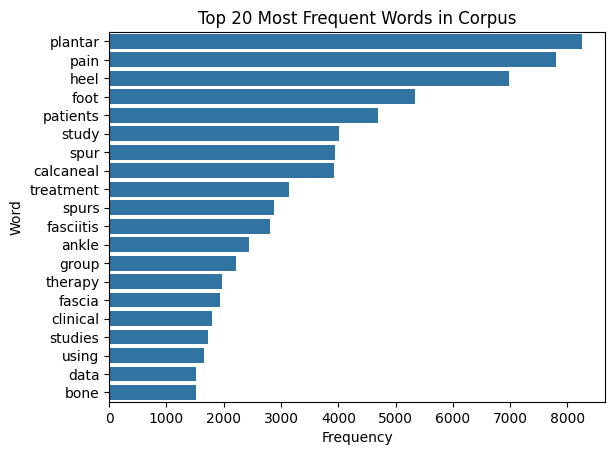

In [11]:
# ==========================================
# PHASE 3: TEXT ANALYSIS EDA
# ==========================================

import re
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS


# ------------------------------------------
# Basic Text Cleaning for Analysis
# ------------------------------------------

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df["clean_text"] = df["raw_text"].apply(clean_text)


# ------------------------------------------
# Tokenization
# ------------------------------------------

df["tokens"] = df["clean_text"].apply(lambda x: x.split())


# ------------------------------------------
# Remove Stopwords
# ------------------------------------------

stopwords = set(ENGLISH_STOP_WORDS)

df["tokens_no_stop"] = df["tokens"].apply(
    lambda words: [w for w in words if w not in stopwords and len(w) > 2]
)


# ------------------------------------------
# Build Corpus Vocabulary
# ------------------------------------------

all_words = []

for words in df["tokens_no_stop"]:
    all_words.extend(words)

word_freq = Counter(all_words)

print("\nTotal Vocabulary Size:", len(word_freq))


# ------------------------------------------
# Top 20 Most Frequent Words
# ------------------------------------------

top_words = word_freq.most_common(20)

freq_df = pd.DataFrame(top_words, columns=["word","frequency"])

print("\nTop 20 Words:")
print(freq_df)


# ------------------------------------------
# Plot Top Words
# ------------------------------------------

plt.figure()

sns.barplot(data=freq_df, x="frequency", y="word")

plt.title("Top 20 Most Frequent Words in Corpus")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

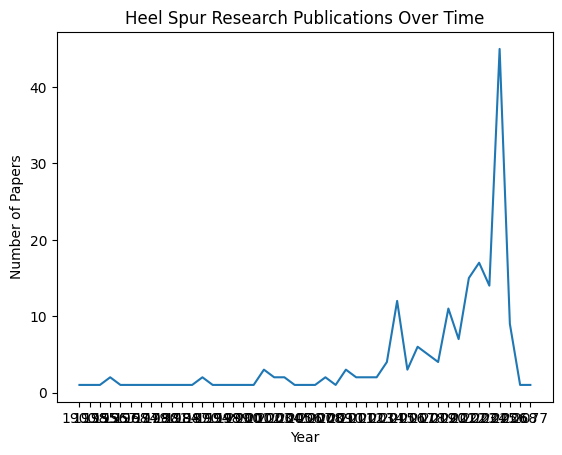

In [12]:
# ==========================================
# RESEARCH TREND ANALYSIS
# ==========================================

papers_per_year = df["Year"].value_counts().sort_index()

plt.figure()

sns.lineplot(
    x=papers_per_year.index,
    y=papers_per_year.values
)

plt.title("Heel Spur Research Publications Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Papers")

plt.show()

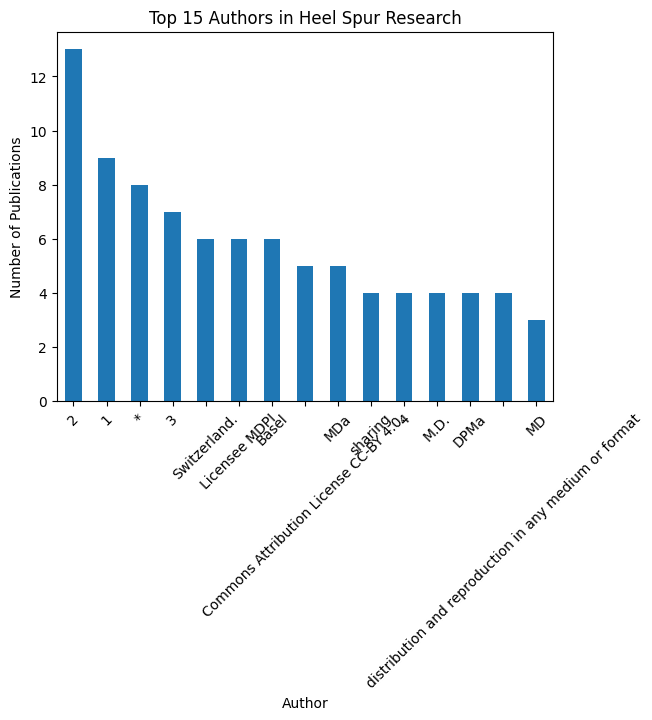

In [13]:
# ==========================================
# AUTHOR PRODUCTIVITY ANALYSIS
# ==========================================

from itertools import chain
import matplotlib.pyplot as plt
import pandas as pd

# Remove missing values
authors = df["Authors"].dropna()

# Split authors by comma
authors = authors.str.split(",")

# Flatten list safely
author_list = list(chain.from_iterable(authors))

# Clean spaces
author_list = [a.strip() for a in author_list if a.strip() != ""]

# Count publications per author
author_counts = pd.Series(author_list).value_counts().head(15)

# Plot
plt.figure()

author_counts.plot(kind="bar")

plt.title("Top 15 Authors in Heel Spur Research")
plt.xlabel("Author")
plt.ylabel("Number of Publications")

plt.xticks(rotation=45)

plt.show()

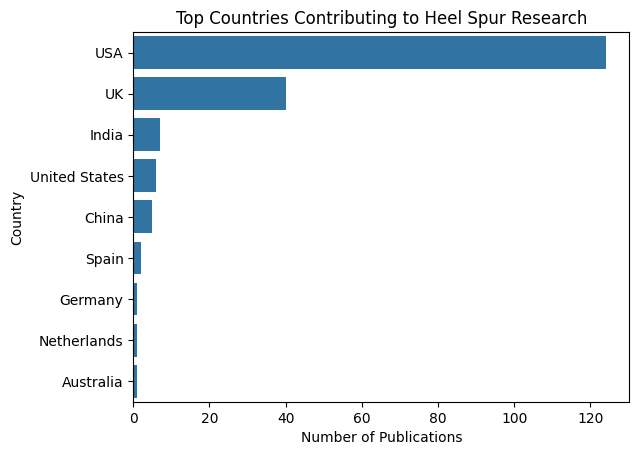

In [14]:
# ==========================================
# COUNTRY CONTRIBUTION ANALYSIS
# ==========================================

country_counts = df["Country"].value_counts().head(10)

plt.figure()

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title("Top Countries Contributing to Heel Spur Research")
plt.xlabel("Number of Publications")
plt.ylabel("Country")

plt.show()

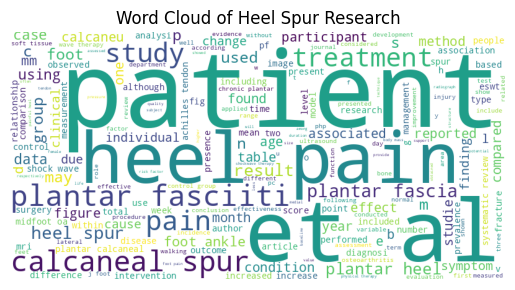

In [15]:
# ==========================================
# WORD CLOUD
# ==========================================

from wordcloud import WordCloud

text = " ".join(df["clean_text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure()

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud of Heel Spur Research")

plt.show()

In [16]:
# ==========================================
# WORD FREQUENCY
# ==========================================

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20
)

X = vectorizer.fit_transform(df["clean_text"])

words = vectorizer.get_feature_names_out()

counts = X.sum(axis=0).A1

word_freq = pd.DataFrame({
    "word": words,
    "count": counts
}).sort_values(by="count", ascending=False)

print(word_freq)

         word  count
12    plantar   8245
10       pain   7808
9        heel   6971
7        foot   5342
11   patients   4687
16      study   4012
13       spur   3946
2   calcaneal   3925
0          al   3467
4          et   3183
18  treatment   3137
14      spurs   2885
6   fasciitis   2815
1       ankle   2435
8       group   2208
17    therapy   1965
5      fascia   1931
3    clinical   1796
15    studies   1725
19      using   1657


          Country  Mentions
2              uk       664
0             usa       479
4           india       215
6       australia       196
7         germany        85
3           china        77
12          kenya        65
1   united states        50
10          spain        50
9           italy        32
11   south africa        19
8          france        16
5          canada        13
13        nigeria         7


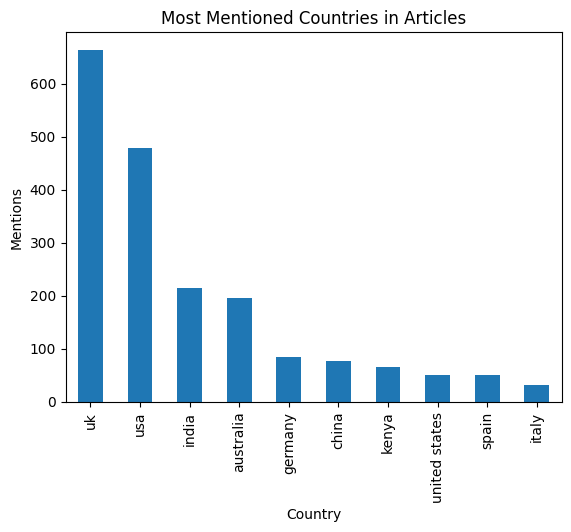

In [17]:
# ==========================================
# MOST MENTIONED COUNTRIES
# ==========================================

import collections

countries = [
    "usa","united states","uk","china","india","canada","australia",
    "germany","france","italy","spain","south africa","kenya","nigeria"
]

country_counts = {}

for country in countries:
    count = df["clean_text"].str.count(country).sum()
    country_counts[country] = count

country_df = pd.DataFrame(
    country_counts.items(),
    columns=["Country","Mentions"]
).sort_values(by="Mentions", ascending=False)

print(country_df)

country_df.head(10).plot(
    x="Country",
    y="Mentions",
    kind="bar",
    legend=False
)

plt.title("Most Mentioned Countries in Articles")
plt.ylabel("Mentions")
plt.show()

          Author  Frequency
0       Menz, H.         23
1   Benjamin, M.         19
2    Landorf, K.         18
3   Maffulli, N.         15
4       Weil, L.         14
5      Zhang, M.         12
6      Rompe, J.         10
7     Ralphs, J.         10
8    Resnick, D.         10
9      Zhang, X.         10
10    Thomas, J.          9
11  Munteanu, S.          9
12   Zwirner, J.          9
13      Wang, C.          9
14     Furia, J.          8


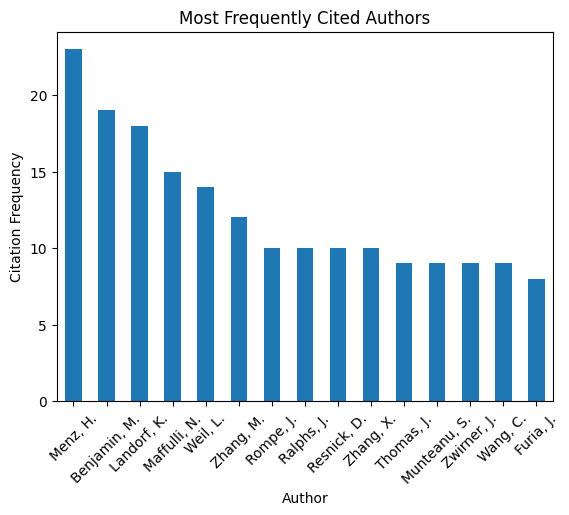

In [18]:
# ==========================================
# MOST FREQUENT AUTHORS
# ==========================================

import re
from collections import Counter

author_pattern = r"\b[A-Z][a-z]+,\s?[A-Z]\."

authors = []

for text in df["raw_text"]:
    found = re.findall(author_pattern, text)
    authors.extend(found)

author_counts = Counter(authors)

top_authors = pd.DataFrame(
    author_counts.most_common(15),
    columns=["Author","Frequency"]
)

print(top_authors)

top_authors.plot(
    x="Author",
    y="Frequency",
    kind="bar",
    legend=False
)

plt.title("Most Frequently Cited Authors")
plt.ylabel("Citation Frequency")
plt.xticks(rotation=45)

plt.show()

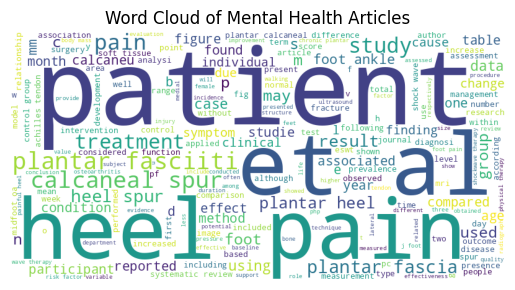

In [19]:
# ==========================================
# WORD CLOUD
# ==========================================

from wordcloud import WordCloud

all_text = " ".join(df["clean_text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_text)

plt.figure()

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud of Mental Health Articles")

plt.show()

  Year  Mentions
1   19      2193
0   20     10660


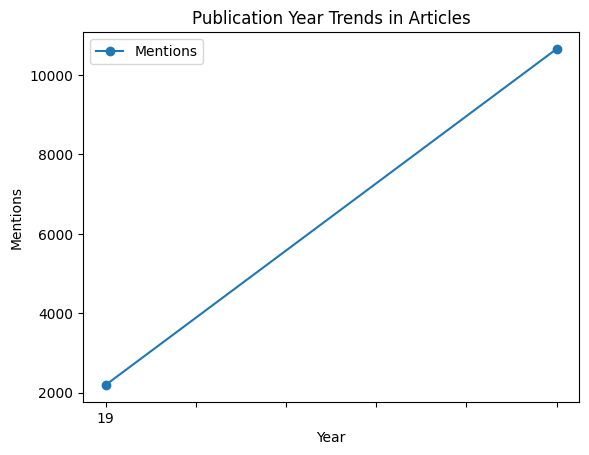

In [20]:
# ==========================================
# PUBLICATION YEAR ANALYSIS
# ==========================================

year_pattern = r"\b(19|20)\d{2}\b"

years = []

for text in df["raw_text"]:
    found = re.findall(year_pattern, text)
    years.extend(found)

year_counts = Counter(years)

year_df = pd.DataFrame(
    year_counts.items(),
    columns=["Year","Mentions"]
).sort_values(by="Year")

print(year_df.tail(10))

year_df.plot(
    x="Year",
    y="Mentions",
    kind="line",
    marker="o"
)

plt.title("Publication Year Trends in Articles")
plt.ylabel("Mentions")

plt.show()

You will learn:

dataset size

average document length

distribution of article sizes

outlier documents

Dataset Shape: (196, 10)

Column Names:
Index(['filename', 'raw_text', 'Title', 'Year', 'Authors', 'Cited_by',
       'Country', 'tokens', 'clean_text', 'tokens_no_stop'],
      dtype='object')

Preview of Dataset:
                                            filename  \
0  Effect of shock wave therapy on pain daily fun...   
1  Comparison of corticosteroid injections and co...   
2  Use of artificial neural networks to identify ...   
3    NON SURGICAL REHABILITATION OF PAINFUL HEEL.pdf   
4  Calcaneal Spurs A Potentially Debilitating Dis...   

                                            raw_text  \
0  Health  Promotion and Physical Activity\nISSN ...   
1  RESEARCH Open Access© The Author(s) 2025. Open...   
2  1 Scientific  RepoRts  |          (2019) 9:420...   
3  402 \n International  Journal  of Academic  Me...   
4  Received\n 08/04/2022 \nReview began\n 08/08/2...   

                                               Title  Year  \
0            Health  Promotion and Physical Activ

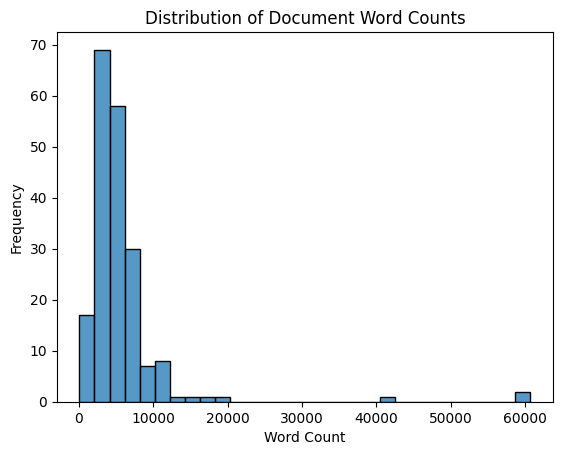


Top 5 Longest Documents:
                                             filename  word_count
31                  CLINICAL SIGNIFICANCE OF HEEL.pdf       60710
55  Foot Structure and Lower Limb Function in Peop...       59093
64  Next-generation lipidic drug delivery systems ...       41038
36  A descriptive study of the prevalence of Acute...       19836
56  Review of CNN-Based Approaches for Preprocessi...       18094

Top 5 Shortest Documents:
                                              filename  word_count
161  Occurrence of calcaneal spurs on skeletal rema...          98
98                                The painful Heel.pdf         326
165  Radiographic Predictors of Surgical Management...         422
146  Plantar heel pain an update of its aetiology a...         434
166  Quantitative Scintigraphy in Diagnosis and Man...         706


In [21]:
# ==========================================
# PHASE 2: BASIC EXPLORATORY DATA ANALYSIS
# ==========================================

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)

print("\nPreview of Dataset:")
print(df.head())


# ------------------------------------------
# Document Length Analysis
# ------------------------------------------

# Count characters
df["char_count"] = df["raw_text"].apply(len)

# Count words
df["word_count"] = df["raw_text"].apply(lambda x: len(x.split()))

print("\nDocument Length Statistics:")
print(df[["char_count", "word_count"]].describe())


# ------------------------------------------
# Distribution of Document Lengths
# ------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df["word_count"], bins=30)
plt.title("Distribution of Document Word Counts")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()


# ------------------------------------------
# Longest and Shortest Documents
# ------------------------------------------

print("\nTop 5 Longest Documents:")
print(df.sort_values("word_count", ascending=False)[["filename","word_count"]].head())

print("\nTop 5 Shortest Documents:")
print(df.sort_values("word_count", ascending=True)[["filename","word_count"]].head())

Typical NLP preprocessing steps:

Lowercase text

Remove punctuation

Remove numbers

Tokenization

Remove stopwords

Lemmatization

Remove very short words

This produces a clean text column for modelling.

reduces noise

standardizes text

improves model accuracy

reduces dimensionality of vocabulary

# 5. Feature Engineering (TF-IDF / BoW)


In [22]:
# ==========================================
# PHASE 4: FEATURE ENGINEERING
# Bag of Words (BoW) and TF-IDF
# ==========================================

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# ------------------------------------------
# Bag of Words Representation
# ------------------------------------------

bow_vectorizer = CountVectorizer(
    max_features=2000,   # limit vocabulary size
    ngram_range=(1,2)    # include unigrams and bigrams
)

X_bow = bow_vectorizer.fit_transform(df["clean_text"])

print("BoW Matrix Shape:", X_bow.shape)


# Convert to DataFrame (optional for inspection)

bow_df = pd.DataFrame(
    X_bow.toarray(),
    columns=bow_vectorizer.get_feature_names_out()
)

print("\nSample BoW Features:")
print(bow_df.iloc[:5, :10])

BoW Matrix Shape: (196, 2000)

Sample BoW Features:
   ab  ab ab  abductor  ability  ability to  able  abnormal  abnormalities  \
0   0      0         0        0           0     0         2              0   
1   0      0         0        1           0     4         0              1   
2   0      0         0        2           0     0         0              1   
3   0      0         5        5           0     0         0              0   
4   0      0         0        0           0     0         0              0   

   about  above  
0      5      2  
1      2      0  
2      0      0  
3      2      0  
4      1      1  


These matrices are what will be used for:

Text similarity

Clustering

Text classification

In [23]:
# ------------------------------------------
# TF-IDF Representation
# ------------------------------------------

tfidf_vectorizer = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1,2)
)

X_tfidf = tfidf_vectorizer.fit_transform(df["clean_text"])

print("TF-IDF Matrix Shape:", X_tfidf.shape)


# Convert to DataFrame (optional for viewing)

tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

print("\nSample TF-IDF Features:")
print(tfidf_df.iloc[:5, :10])

TF-IDF Matrix Shape: (196, 2000)

Sample TF-IDF Features:
    ab  ab ab  abductor   ability  ability to      able  abnormal  \
0  0.0    0.0  0.000000  0.000000         0.0  0.000000  0.007266   
1  0.0    0.0  0.000000  0.003274         0.0  0.015136  0.000000   
2  0.0    0.0  0.000000  0.007453         0.0  0.000000  0.000000   
3  0.0    0.0  0.028467  0.024427         0.0  0.000000  0.000000   
4  0.0    0.0  0.000000  0.000000         0.0  0.000000  0.000000   

   abnormalities     about     above  
0       0.000000  0.013828  0.006674  
1       0.003444  0.005244  0.000000  
2       0.003920  0.000000  0.000000  
3       0.000000  0.007824  0.000000  
4       0.000000  0.003495  0.004217  


In [24]:
# ------------------------------------------
# Top TF-IDF Terms
# ------------------------------------------

feature_names = tfidf_vectorizer.get_feature_names_out()

print("Sample vocabulary terms:")
print(feature_names[:20])

Sample vocabulary terms:
['ab' 'ab ab' 'abductor' 'ability' 'ability to' 'able' 'abnormal'
 'abnormalities' 'about' 'above' 'absence' 'absence of' 'abstract'
 'accepted' 'access' 'according' 'according to' 'accuracy' 'achieved'
 'achilles']


In [25]:
# ==========================================
# Identify Most Important TF-IDF Words
# ==========================================

import numpy as np

mean_tfidf = np.mean(X_tfidf.toarray(), axis=0)

top_indices = mean_tfidf.argsort()[-20:][::-1]

top_words = [(feature_names[i], mean_tfidf[i]) for i in top_indices]

top_words_df = pd.DataFrame(top_words, columns=["Word","TF-IDF Score"])

print(top_words_df)

         Word  TF-IDF Score
0         the      0.429391
1          of      0.327477
2         and      0.258933
3          in      0.167272
4          to      0.126211
5     plantar      0.099866
6        with      0.094613
7      of the      0.085349
8        pain      0.082792
9        heel      0.078528
10        was      0.069641
11        for      0.067479
12  calcaneal      0.061246
13         is      0.060198
14       spur      0.055653
15   patients      0.053687
16       foot      0.050582
17       were      0.047954
18         on      0.043493
19         as      0.043410


6. Text Similarity Analysis


This is useful for:

detecting related articles

identifying duplicate or near-duplicate documents

understanding topic relationships in the corpus

# PHASE 5: TEXT SIMILARITY ANALYSIS

We will compute Cosine Similarity, which is the most common similarity metric for TF-IDF vectors.

Cosine similarity measures the angle between document vectors, giving a value between:

1 → identical documents

0 → completely unrelated

In [26]:
# ==========================================
# TEXT SIMILARITY MATRIX
# ==========================================

from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(X_tfidf)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=df["Title"],
    columns=df["Title"]
)

print(similarity_df.head())

Title                                               Health  Promotion and Physical Activity  \
Title                                                                                         
Health  Promotion and Physical Activity                                            1.000000   
RESEARCH Open Access© The Author(s) 2025. Open ...                                 0.772688   
1 Scientific  RepoRts  |          (2019) 9:4207...                                 0.808687   
International  Journal  of Academic  Medicine  ...                                 0.660521   
None                                                                               0.774437   

Title                                               RESEARCH Open Access© The Author(s) 2025. Open Access   This article is licensed under a Creative Commons Attribution-NonCommercial-NoDerivatives 4.0  \
Title                                                                                                                            

In [27]:
# ==========================================
# KEYWORD CO-OCCURRENCE
# ==========================================

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=30
)

X = vectorizer.fit_transform(df["clean_text"])

import numpy as np

co_occurrence = (X.T * X)

co_occurrence.setdiag(0)

co_occurrence_matrix = co_occurrence.toarray()

print(co_occurrence_matrix)

[[      0   55427   16264   48119   17272   46136   25448   23710   39458
    16302   21514  100757   29613  123778   12504  110419   12346   57280
    95468   19875   14191   17369   44587   37949   25842   55762   15824
    27585   15880   18523]
 [  55427       0   42980   91901   51817   87960   75055   72461  155438
    47890   62632  226362   76004  408012   48041  364735   37028  144634
   247449   47308   45114   60367   81982   61020   77236  127139   70034
    93910   51902   64255]
 [  16264   42980       0   28708   17024   25475   27849   27066   35196
    16849   18181   91623   25534   66613   12465   75710    9404   39248
    69267   25291   13995   20745   25531   18655   36687   51147   18915
    28207   18361   25259]
 [  48119   91901   28708       0   27961   58515   59175   42636   74552
    36544   45943  279552   51980  169409   25313  209171   30203   87740
   165728   46767   22833   41900   44583   26676   58639  111898   34481
    53488   27875   33961]
 [  

In [28]:
# ==========================================
# PHASE 5: TEXT SIMILARITY ANALYSIS
# ==========================================

from sklearn.metrics.pairwise import cosine_similarity

# Compute similarity matrix
similarity_matrix = cosine_similarity(X_tfidf)

print("Similarity Matrix Shape:", similarity_matrix.shape)

Similarity Matrix Shape: (196, 196)


In [29]:
# Convert to DataFrame for readability

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=df["filename"],
    columns=df["filename"]
)

print(similarity_df.head())

filename                                            Effect of shock wave therapy on pain daily functioning in patients with heel spurs.pdf  \
filename                                                                                                                                     
Effect of shock wave therapy on pain daily func...                                           1.000000                                        
Comparison of corticosteroid injections and con...                                           0.772688                                        
Use of artificial neural networks to identify t...                                           0.808687                                        
NON SURGICAL REHABILITATION OF PAINFUL HEEL.pdf                                              0.660521                                        
Calcaneal Spurs A Potentially Debilitating Diso...                                           0.774437                                        

filen

In [30]:
# ==========================================
# Find Most Similar Documents
# ==========================================

def get_top_similar(doc_index, top_n=5):

    sim_scores = list(enumerate(similarity_matrix[doc_index]))

    # sort by similarity score
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # remove self similarity
    sim_scores = sim_scores[1:top_n+1]

    similar_docs = [(df.iloc[i]["filename"], score) for i, score in sim_scores]

    return similar_docs


# Example: similar documents to the first article

print("Documents similar to:", df.iloc[0]["filename"])
print(get_top_similar(0))

Documents similar to: Effect of shock wave therapy on pain daily functioning in patients with heel spurs.pdf
[('Evaluation of the Effectiveness of Comprehensive Physiotherapy in Relieving Pain in Patients with Heel Spurs.pdf', np.float64(0.8829092484060386)), ('New treatment interventions of calcaneal spurs.pdf', np.float64(0.8383079992555997)), ('Chosen Conservative Treatments on the Symptoms of Calcaneal Spur.pdf', np.float64(0.8353873967344159)), ('Use of artificial neural networks to identify the predictive factors of extracorporeal shock wave therapy treating patients.pdf', np.float64(0.8086865160738969)), ('CLINICAL SIGNIFICANCE OF HEEL.pdf', np.float64(0.8028052362882502))]


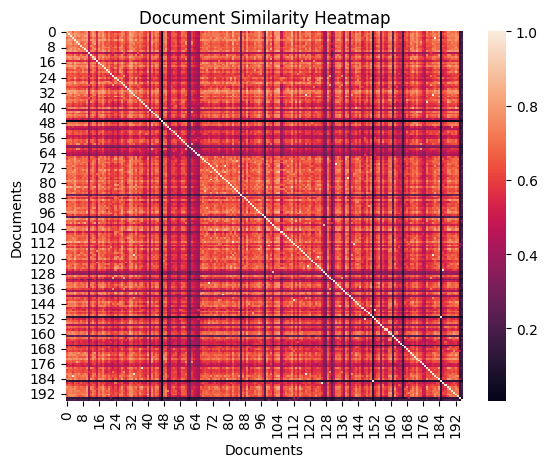

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()

sns.heatmap(similarity_matrix)

plt.title("Document Similarity Heatmap")

plt.xlabel("Documents")
plt.ylabel("Documents")

plt.show()

# 7. Clustering Analysis


Clustering will:

group similar mental health articles

discover hidden themes

help interpret topics within the datase

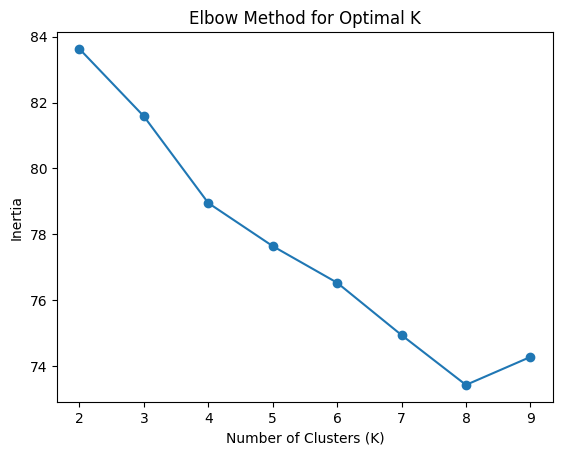

In [32]:
# ==========================================
# PHASE 6: CLUSTERING
# Determine Optimal Clusters (Elbow Method)
# ==========================================

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 10)

for k in K_range:

    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_tfidf)

    inertia.append(model.inertia_)

plt.figure()

plt.plot(K_range, inertia, marker='o')

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()

In [33]:
# ==========================================
# Apply K-Means Clustering
# ==========================================

k = 4

kmeans = KMeans(n_clusters=k, random_state=42)

clusters = kmeans.fit_predict(X_tfidf)

df["cluster"] = clusters

print(df[["filename","cluster"]].head())

                                            filename  cluster
0  Effect of shock wave therapy on pain daily fun...        3
1  Comparison of corticosteroid injections and co...        3
2  Use of artificial neural networks to identify ...        2
3    NON SURGICAL REHABILITATION OF PAINFUL HEEL.pdf        3
4  Calcaneal Spurs A Potentially Debilitating Dis...        0


cluster
3    110
0     50
2     19
1     17
Name: count, dtype: int64


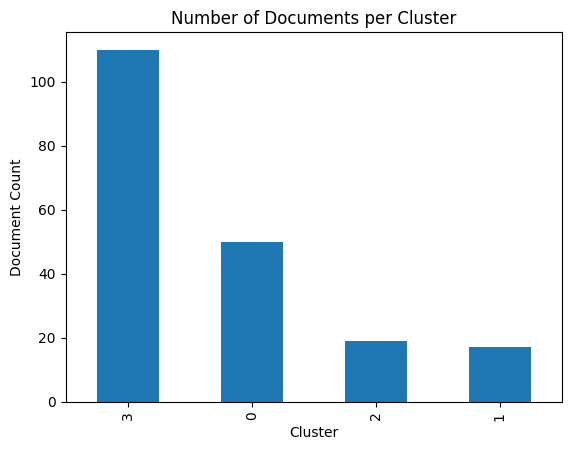

In [34]:
# ==========================================
# Cluster Size Distribution
# ==========================================

cluster_counts = df["cluster"].value_counts()

print(cluster_counts)

cluster_counts.plot(kind="bar")

plt.title("Number of Documents per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Document Count")

plt.show()

In [35]:
# ==========================================
# Top Words Per Cluster
# ==========================================

import numpy as np

terms = tfidf_vectorizer.get_feature_names_out()

order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(k):

    print(f"\nCluster {i} Top Words:")

    for ind in order_centroids[i, :10]:
        print(terms[ind])


Cluster 0 Top Words:
the
of
and
in
plantar
calcaneal
spur
to
spurs
heel

Cluster 1 Top Words:
the
of
and
in
preprint
to
medrxiv
by
pollen
drop

Cluster 2 Top Words:
the
of
and
in
eswt
to
therapy
pain
treatment
with

Cluster 3 Top Words:
the
of
and
in
to
with
of the
pain
plantar
heel


Cluster 0 → depression treatment therapy
Cluster 1 → anxiety stress emotional
Cluster 2 → mental health awareness
Cluster 3 → psychological research studies

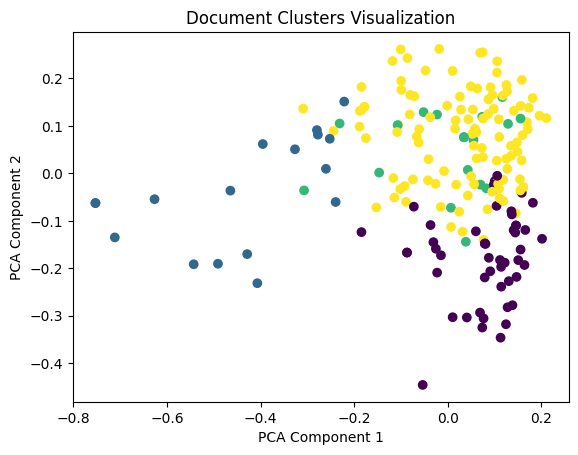

In [36]:
# ==========================================
# Cluster Visualization
# ==========================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

reduced_features = pca.fit_transform(X_tfidf.toarray())

plt.figure()

plt.scatter(
    reduced_features[:,0],
    reduced_features[:,1],
    c=df["cluster"]
)

plt.title("Document Clusters Visualization")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()

Cluster 0 → depression treatment therapy
Cluster 1 → anxiety stress emotional
Cluster 2 → mental health awareness
Cluster 3 → psychological research studies

PHASE 7: TEXT CLASSIFICATION

Goal:

Train machine learning models to predict document clusters based on textual features.

We will compare multiple algorithms to see which performs best.

9. Text Classification


In [37]:
# ==========================================
# PHASE 7: TEXT CLASSIFICATION
# ==========================================

X = X_tfidf
y = df["cluster"]

print("Feature Matrix Shape:", X.shape)
print("Target Distribution:")
print(y.value_counts())

Feature Matrix Shape: (196, 2000)
Target Distribution:
cluster
3    110
0     50
2     19
1     17
Name: count, dtype: int64


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 156
Testing samples: 40


In [39]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_predictions = nb_model.predict(X_test)

In [40]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

# 8. Topic Modelling


In [42]:
# ==========================================
# TOPIC MODELING (LDA)
# ==========================================

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Convert text to document-term matrix
vectorizer = CountVectorizer(
    stop_words="english",
    max_df=0.9,
    min_df=2
)

dtm = vectorizer.fit_transform(df["raw_text"])

# Train LDA model
lda = LatentDirichletAllocation(
    n_components=5,   # number of research topics
    random_state=42
)

lda.fit(dtm)

# Assign dominant topic to each paper
topic_results = lda.transform(dtm)

df["dominant_topic"] = topic_results.argmax(axis=1)

print(df[["Title","dominant_topic"]].head())

                                               Title  dominant_topic
0            Health  Promotion and Physical Activity               0
1  RESEARCH Open Access© The Author(s) 2025. Open...               0
2  1 Scientific  RepoRts  |          (2019) 9:420...               0
3  International  Journal  of Academic  Medicine ...               0
4                                               None               0


In [43]:
# ==========================================
# PHASE 9: TOPIC MODELLING
# ==========================================

from sklearn.decomposition import LatentDirichletAllocation

In [44]:
n_topics = 5

lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42
)

lda_model.fit(X_bow)

LatentDirichletAllocation(n_components=5, random_state=42)

In [45]:
# ==========================================
# Document Topic Assignment
# ==========================================

doc_topics = lda_model.transform(X_bow)

df["dominant_topic"] = doc_topics.argmax(axis=1)

print(df[["filename", "dominant_topic"]].head())

                                            filename  dominant_topic
0  Effect of shock wave therapy on pain daily fun...               1
1  Comparison of corticosteroid injections and co...               1
2  Use of artificial neural networks to identify ...               1
3    NON SURGICAL REHABILITATION OF PAINFUL HEEL.pdf               3
4  Calcaneal Spurs A Potentially Debilitating Dis...               1


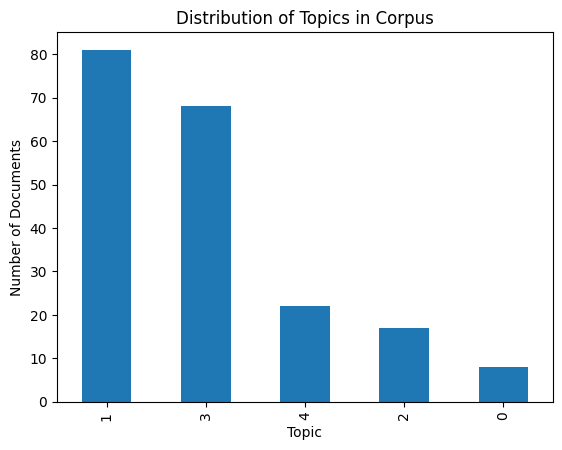

In [46]:
import matplotlib.pyplot as plt

df["dominant_topic"].value_counts().plot(kind="bar")

plt.title("Distribution of Topics in Corpus")
plt.xlabel("Topic")
plt.ylabel("Number of Documents")

plt.show()

10. Model Evaluation


Accuracy

Precision

Recall

F1-score

In [47]:
from sklearn.metrics import classification_report, accuracy_score

In [48]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_predictions))

print("\nNaive Bayes Classification Report:")
print(classification_report(y_test, nb_predictions))

Naive Bayes Accuracy: 0.575

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.00      0.00      0.00         5
           2       0.00      0.00      0.00         2
           3       0.57      1.00      0.73        23

    accuracy                           0.57        40
   macro avg       0.14      0.25      0.18        40
weighted avg       0.33      0.57      0.42        40



In [49]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_predictions))

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, lr_predictions))

Logistic Regression Accuracy: 0.825

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       1.00      0.20      0.33         5
           2       0.00      0.00      0.00         2
           3       0.79      1.00      0.88        23

    accuracy                           0.82        40
   macro avg       0.67      0.53      0.53        40
weighted avg       0.81      0.82      0.78        40



In [50]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.9

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       1.00      0.40      0.57         5
           2       1.00      1.00      1.00         2
           3       0.85      1.00      0.92        23

    accuracy                           0.90        40
   macro avg       0.96      0.82      0.86        40
weighted avg       0.91      0.90      0.89        40



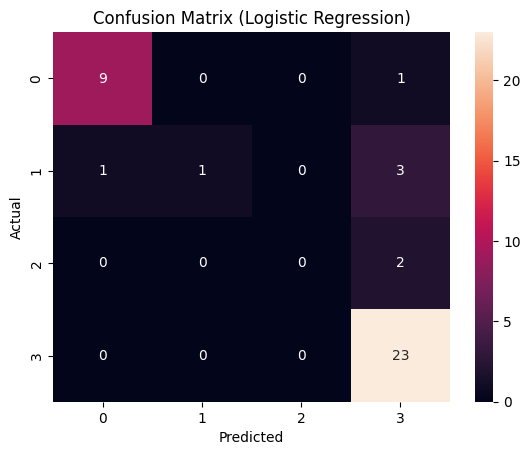

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_predictions)

plt.figure()

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

11. Discussion of Results


In [52]:
# ==========================================
# PHASE 8: MODEL COMPARISON
# ==========================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_true, y_pred):

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted"),
        "Recall": recall_score(y_true, y_pred, average="weighted"),
        "F1 Score": f1_score(y_true, y_pred, average="weighted")
    }

In [53]:
nb_results = evaluate_model(y_test, nb_predictions)

lr_results = evaluate_model(y_test, lr_predictions)

rf_results = evaluate_model(y_test, rf_predictions)

In [54]:
import pandas as pd

model_comparison = pd.DataFrame({

    "Naive Bayes": nb_results,
    "Logistic Regression": lr_results,
    "Random Forest": rf_results

}).T

print(model_comparison)

                     Accuracy  Precision  Recall  F1 Score
Naive Bayes             0.575   0.330625   0.575  0.419841
Logistic Regression     0.825   0.806034   0.825  0.775321
Random Forest           0.900   0.914815   0.900  0.887271


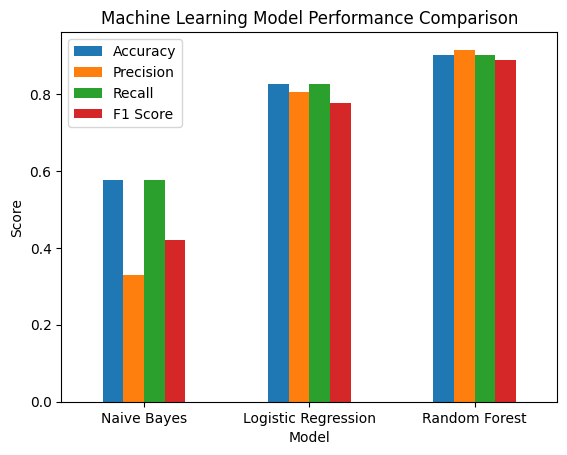

In [55]:
import matplotlib.pyplot as plt

model_comparison.plot(kind="bar")

plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")

plt.xticks(rotation=0)

plt.show()

12. Conclusion
